# Cross-Patient Auto ARIMA — Single Global Order

This notebook fits **one global ARIMA order** shared across all patients, rather than
selecting a different order per patient.

## Approach
1. **Order discovery** — run `auto_arima` on each *train-split* patient's training
   portion to find their individually optimal (p, d, q).
2. **Global order selection** — evaluate each candidate order via rolling one-step-ahead
   RMSE on **val-split patients**. Pick the order with the lowest mean val RMSE.
   This is consistent with the non-temporal notebooks (classification/regression),
   which also select models by val-set performance.
3. **Refit with fixed order** — fit `ARIMA(p*, d*, q*)` for every patient (train / val /
   test) using the globally selected order.
4. **Rolling one-step-ahead forecast** — update model after each true observation.
5. **Evaluation** — RMSE, MAE, R² on the held-out 40 % of each patient's series;
   compare with per-patient auto ARIMA results.

## Why a shared order?
A single (p, d, q) order forces the model to learn a structure that is generalisable
across patients rather than over-fitting each short individual series. It also makes
the model interpretable: one set of AR and MA lags describes mood dynamics for
*everyone*, and new patients can be fitted immediately without an order-selection step.

## Split usage (consistent with non-temporal notebooks)
| Split | Role |
|---|---|
| **Train patients** | Auto ARIMA order candidate generation |
| **Val patients** | Global order selection (min mean val RMSE) |
| **Test patients** | Final evaluation only — never used during selection |

In [23]:
import sys
import warnings
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm import tqdm

try:
    from pmdarima import auto_arima
    from pmdarima.arima import ARIMA
except ImportError:
    raise ImportError("Install pmdarima first:  pip install pmdarima")

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()),
    Path.cwd(),
)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

DATA_DIR = _root / "data"


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

---
## 1. Load data

In [24]:
raw = pd.read_parquet(DATA_DIR / "1b_dataset_cleaned.parquet")
splits_df = pd.read_parquet(DATA_DIR / "1b_dataset_target_splits.parquet")

print(f"Raw records : {len(raw):,}")
print(f"Patients    : {raw['id'].nunique()}")
print("\nSplit assignments:")
print(splits_df["split"].value_counts().to_string())

Raw records : 376,413
Patients    : 27

Split assignments:
split
train    846
test     267
val      155


---
## 2. Build daily mood series

In [25]:
mood_raw = (
    raw[raw["variable"] == "mood"]
    .copy()
    .assign(date=lambda df: df["time"].dt.normalize())
    .groupby(["id", "date"])["value"]
    .mean()
    .reset_index()
    .rename(columns={"value": "mood"})
)

patient_splits = splits_df[["id", "split"]].drop_duplicates(subset="id")
mood_raw = mood_raw.merge(patient_splits, on="id", how="left")

print(f"Daily mood records : {len(mood_raw):,}")
print(f"Patients           : {mood_raw['id'].nunique()}")
print("\nPatients per split:")
print(mood_raw.groupby("split")["id"].nunique().rename("n_patients").to_string())

Daily mood records : 1,268
Patients           : 27

Patients per split:
split
test      6
train    18
val       3


---
## 3. Helper functions

In [26]:
def build_patient_series(patient_df: pd.DataFrame):
    """Return a gap-free date-indexed mood Series and an observed-day boolean mask."""
    s = patient_df.set_index("date")["mood"].sort_index()
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq="D")
    s = s.reindex(full_idx)
    observed_mask = s.notna()
    s = s.ffill().bfill()
    return s, observed_mask


def train_test_split_series(series, obs_mask, train_frac=0.6):
    """Split a patient series at train_frac of their *observed* days."""
    observed_dates = sorted(obs_mask[obs_mask].index)
    cutoff_idx = int(len(observed_dates) * train_frac)
    cutoff_date = observed_dates[cutoff_idx - 1]
    train = series[series.index <= cutoff_date]
    test = series[series.index > cutoff_date]
    test_mask = obs_mask[obs_mask.index > cutoff_date]
    return train, test, test_mask


def rolling_forecast(model, test_series: pd.Series, observed_mask: pd.Series):
    """Rolling one-step-ahead forecast; updates model with true value each step."""
    y_true_list, y_pred_list, dates = [], [], []
    for date, actual in test_series.items():
        forecast = float(model.predict(n_periods=1)[0])
        forecast = float(np.clip(forecast, 1.0, 10.0))
        if observed_mask.get(date, False):
            y_true_list.append(actual)
            y_pred_list.append(forecast)
            dates.append(date)
        model.update([actual])
    return np.array(y_true_list), np.array(y_pred_list), dates


print("Helpers defined.")

Helpers defined.


---
## 4. Phase 1 — Discover order candidates from train patients

We run `auto_arima` on the training portion (first 60 % of observed days) of each
**train-split** patient's series to collect a set of candidate (p, d, q) orders.

These candidates are then evaluated on **val-split patients** in Phase 2 to select
the single best global order — consistent with how the non-temporal notebooks use the
val split for model selection.

In [27]:
train_patients = mood_raw[mood_raw["split"] == "train"]["id"].unique()
print(f"Training patients: {len(train_patients)}")

# Step 1: collect auto_arima-selected orders for each training patient
candidate_orders = []  # list of (p, d, q) tuples
train_series_cache = {}  # cache (train_series, test_series, test_mask) per patient

for pid in tqdm(train_patients, desc="Auto ARIMA order discovery (train patients)"):
    pdf = mood_raw[mood_raw["id"] == pid]
    series, obs_mask = build_patient_series(pdf[["date", "mood"]])

    observed_dates = sorted(obs_mask[obs_mask].index)
    if len(observed_dates) < 10:
        continue

    train_s, test_s, test_mask = train_test_split_series(series, obs_mask)
    train_series_cache[pid] = (train_s, test_s, test_mask)

    try:
        model = auto_arima(
            train_s.values,
            start_p=0,
            max_p=5,
            start_q=0,
            max_q=2,
            d=None,
            max_d=1,
            seasonal=False,
            stepwise=True,
            information_criterion="aic",
            error_action="ignore",
            suppress_warnings=True,
            random_state=RANDOM_STATE,
        )
        candidate_orders.append(model.order)
    except Exception:
        pass

order_counts = Counter(candidate_orders)
print(f"\nOrder candidates discovered: {len(candidate_orders)}")
print("\nTop-10 most common orders (p, d, q):")
for order, cnt in order_counts.most_common(10):
    print(f"  {order}  →  {cnt} patients")

Training patients: 18


Auto ARIMA order discovery (train patients): 100%|██████████| 18/18 [00:02<00:00,  6.43it/s]


Order candidates discovered: 18

Top-10 most common orders (p, d, q):
  (0, 0, 0)  →  8 patients
  (0, 0, 1)  →  3 patients
  (1, 0, 0)  →  2 patients
  (0, 1, 1)  →  2 patients
  (3, 1, 0)  →  1 patients
  (1, 0, 1)  →  1 patients
  (0, 0, 2)  →  1 patients


In [28]:
# Phase 2: build val patient series cache and select global order by val RMSE
val_patients = mood_raw[mood_raw["split"] == "val"]["id"].unique()
print(f"Validation patients: {len(val_patients)}")

val_series_cache = {}
for pid in val_patients:
    pdf = mood_raw[mood_raw["id"] == pid]
    series, obs_mask = build_patient_series(pdf[["date", "mood"]])
    observed_dates = sorted(obs_mask[obs_mask].index)
    if len(observed_dates) < 10:
        continue
    train_s, test_s, test_mask = train_test_split_series(series, obs_mask)
    val_series_cache[pid] = (train_s, test_s, test_mask)

print(f"Val series cached: {len(val_series_cache)} patients")

# For each candidate order, evaluate rolling one-step-ahead RMSE on val patients.
# The order with the lowest mean val RMSE is selected — mirrors val-based model
# selection in the classification and regression notebooks.
unique_orders = list(order_counts.keys())
print(f"\nEvaluating {len(unique_orders)} candidate orders on val patients…\n")

order_val_rmse = {}

for order in tqdm(unique_orders, desc="Evaluating orders on val patients"):
    p, d, q = order
    rmse_list = []
    for pid, (train_s, test_s, test_mask) in val_series_cache.items():
        try:
            m = ARIMA(order=(p, d, q))
            m.fit(train_s.values)
            y_true, y_pred, _ = rolling_forecast(m, test_s, test_mask)
            if len(y_true) > 0:
                rmse_list.append(rmse(y_true, y_pred))
        except Exception:
            pass
    if rmse_list:
        order_val_rmse[order] = np.mean(rmse_list)

best_order = min(order_val_rmse, key=order_val_rmse.get)

print(f"\nGlobal best order: ARIMA{best_order}")
print(f"Mean val RMSE: {order_val_rmse[best_order]:.4f}")
print("\nAll candidate orders ranked by val RMSE (lower is better):")
for order, r in sorted(order_val_rmse.items(), key=lambda x: x[1]):
    marker = "  ← selected" if order == best_order else ""
    n_auto = order_counts.get(order, 0)
    print(
        f"  ARIMA{order}  val RMSE={r:.4f}  (auto_arima choice of {n_auto} train patients){marker}"
    )

Validation patients: 3
Val series cached: 3 patients

Evaluating 7 candidate orders on val patients…



Evaluating orders on val patients: 100%|██████████| 7/7 [00:03<00:00,  2.22it/s]


Global best order: ARIMA(1, 0, 0)
Mean val RMSE: 0.4103

All candidate orders ranked by val RMSE (lower is better):
  ARIMA(1, 0, 0)  val RMSE=0.4103  (auto_arima choice of 2 train patients)  ← selected
  ARIMA(0, 0, 1)  val RMSE=0.4116  (auto_arima choice of 3 train patients)
  ARIMA(0, 0, 2)  val RMSE=0.4184  (auto_arima choice of 1 train patients)
  ARIMA(1, 0, 1)  val RMSE=0.4225  (auto_arima choice of 1 train patients)
  ARIMA(0, 0, 0)  val RMSE=0.4365  (auto_arima choice of 8 train patients)
  ARIMA(3, 1, 0)  val RMSE=0.4797  (auto_arima choice of 1 train patients)
  ARIMA(0, 1, 1)  val RMSE=0.5014  (auto_arima choice of 2 train patients)


---
## 5. Phase 3 — Refit all patients with the global order

Every patient (train / val / test) is now fitted with `ARIMA(p*, d*, q*)` — the
single order selected in Phase 2 by **val RMSE**. Rolling one-step-ahead forecasting
proceeds as before: the model is updated with each true observation after predicting it.

The test patients were not involved in any selection step.

In [29]:
p_star, d_star, q_star = best_order
print(f"Fitting ARIMA{best_order} for all patients…\n")

results = []

for pid, pdf in tqdm(mood_raw.groupby("id"), desc="Fitting fixed-order ARIMA"):
    patient_split = pdf["split"].iloc[0]
    series, obs_mask = build_patient_series(pdf[["date", "mood"]])

    observed_dates = sorted(obs_mask[obs_mask].index)
    if len(observed_dates) < 10:
        continue

    train_s, test_s, test_mask = train_test_split_series(series, obs_mask)

    if len(test_s) == 0 or test_mask.sum() == 0:
        continue

    try:
        model = ARIMA(order=(p_star, d_star, q_star))
        model.fit(train_s.values)
        y_true, y_pred, dates = rolling_forecast(model, test_s, test_mask)
    except Exception as e:
        print(f"  Patient {pid}: fit failed ({e}), skipping.")
        continue

    results.append(
        {
            "patient_id": pid,
            "split": patient_split,
            "y_true": y_true,
            "y_pred": y_pred,
            "dates": dates,
            "n_train": int(obs_mask[obs_mask.index <= train_s.index[-1]].sum()),
            "n_test": len(y_true),
        }
    )

print(f"\nFitted {len(results)} patients with ARIMA{best_order}.")

Fitting ARIMA(1, 0, 0) for all patients…



Fitting fixed-order ARIMA: 100%|██████████| 27/27 [00:03<00:00,  7.51it/s]


Fitted 27 patients with ARIMA(1, 0, 0).


---
## 6. Evaluation metrics

In [30]:
def aggregate_metrics(result_list, label=""):
    y_true_all = np.concatenate([r["y_true"] for r in result_list])
    y_pred_all = np.concatenate([r["y_pred"] for r in result_list])
    r = {
        "split": label,
        "n_pred": len(y_true_all),
        "RMSE": round(rmse(y_true_all, y_pred_all), 4),
        "MAE": round(mean_absolute_error(y_true_all, y_pred_all), 4),
        "R2": round(r2_score(y_true_all, y_pred_all), 4),
    }
    print(
        f"  {label:10s}  n={r['n_pred']:>4}  RMSE={r['RMSE']:.4f}  MAE={r['MAE']:.4f}  R²={r['R2']:.4f}"
    )
    return r, y_true_all, y_pred_all


print(f"Cross-patient ARIMA{best_order} — rolling one-step-ahead forecast\n")

train_res = [r for r in results if r["split"] == "train"]
val_res = [r for r in results if r["split"] == "val"]
test_res = [r for r in results if r["split"] == "test"]

metrics_rows = []
for subset, label in [(train_res, "train"), (val_res, "val"), (test_res, "test")]:
    if subset:
        m, _, _ = aggregate_metrics(subset, label)
        metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows)

_, y_test_true, y_test_pred = aggregate_metrics(test_res, "test (plots)")

Cross-patient ARIMA(1, 0, 0) — rolling one-step-ahead forecast

  train       n= 348  RMSE=0.6942  MAE=0.5035  R²=0.3012
  val         n=  63  RMSE=0.4083  MAE=0.2776  R²=0.1381
  test        n= 108  RMSE=0.5036  MAE=0.3940  R²=-0.0069
  test (plots)  n= 108  RMSE=0.5036  MAE=0.3940  R²=-0.0069


---
## 7. Per-patient performance

In [31]:
per_patient = []
for r in results:
    if len(r["y_true"]) == 0:
        continue
    per_patient.append(
        {
            "patient_id": r["patient_id"],
            "split": r["split"],
            "RMSE": round(rmse(r["y_true"], r["y_pred"]), 4),
            "MAE": round(mean_absolute_error(r["y_true"], r["y_pred"]), 4),
            "n_test_days": r["n_test"],
        }
    )

pp_df = pd.DataFrame(per_patient).sort_values("RMSE")
print("Per-patient RMSE (sorted):")
print(pp_df.to_string(index=False))

Per-patient RMSE (sorted):
patient_id split   RMSE    MAE  n_test_days
   AS14.31 train 0.1887 0.1164           18
   AS14.30 train 0.2241 0.1693           19
   AS14.03  test 0.2923 0.2229           19
   AS14.20 train 0.3286 0.2451           19
   AS14.15   val 0.3631 0.2162           22
   AS14.17   val 0.3727 0.2697           23
   AS14.05 train 0.3932 0.3098           22
   AS14.25  test 0.4370 0.3579           12
   AS14.24  test 0.4415 0.3249           22
   AS14.14   val 0.4950 0.3627           18
   AS14.19 train 0.5242 0.4149           19
   AS14.01  test 0.5365 0.4521           19
   AS14.27  test 0.5458 0.4664           17
   AS14.12 train 0.5606 0.4967           17
   AS14.29 train 0.5639 0.4179           17
   AS14.06 train 0.5680 0.4711           18
   AS14.28 train 0.5845 0.4777           16
   AS14.08 train 0.6058 0.5166           25
   AS14.23 train 0.6148 0.4681           16
   AS14.16 train 0.6491 0.5065           22
   AS14.26 train 0.6554 0.5421           28
   AS

---
## 8. Residual analysis (test patients)

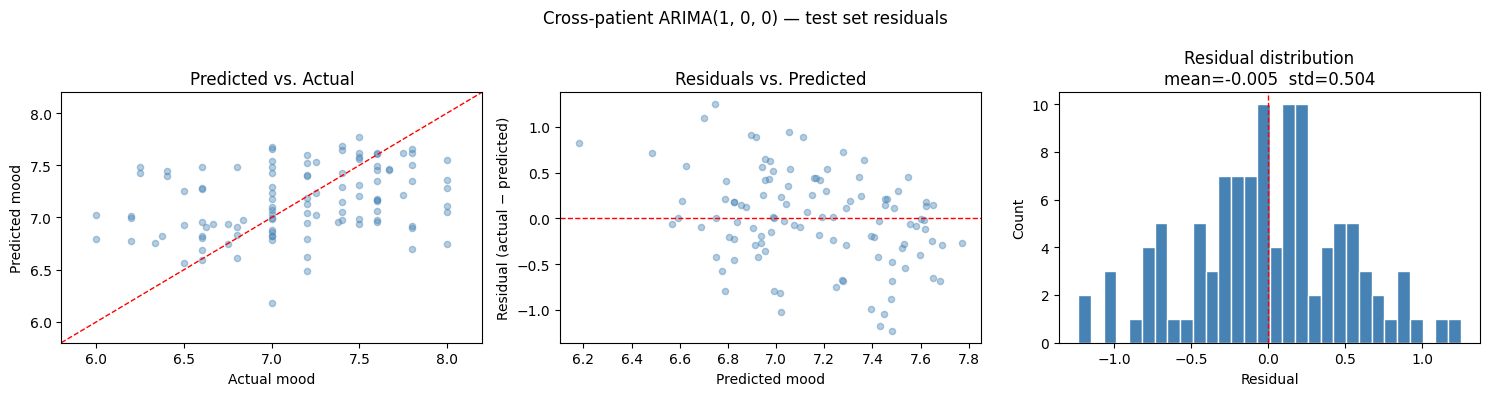

Saved: arima_cross_residuals.png


In [32]:
residuals = y_test_true - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.scatter(y_test_true, y_test_pred, alpha=0.4, s=20, color="steelblue")
lims = [
    min(y_test_true.min(), y_test_pred.min()) - 0.2,
    max(y_test_true.max(), y_test_pred.max()) + 0.2,
]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Actual mood")
ax.set_ylabel("Predicted mood")
ax.set_title("Predicted vs. Actual")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax = axes[1]
ax.scatter(y_test_pred, residuals, alpha=0.4, s=20, color="steelblue")
ax.axhline(0, color="red", linewidth=1, linestyle="--")
ax.set_xlabel("Predicted mood")
ax.set_ylabel("Residual (actual − predicted)")
ax.set_title("Residuals vs. Predicted")

ax = axes[2]
ax.hist(residuals, bins=30, color="steelblue", edgecolor="white")
ax.axvline(0, color="red", linewidth=1, linestyle="--")
ax.set_xlabel("Residual")
ax.set_ylabel("Count")
ax.set_title(
    f"Residual distribution\nmean={residuals.mean():.3f}  std={residuals.std():.3f}"
)

plt.suptitle(f"Cross-patient ARIMA{best_order} — test set residuals", fontsize=12)
plt.tight_layout()
plt.savefig("arima_cross_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: arima_cross_residuals.png")

---
## 9. Example forecasts for selected test patients

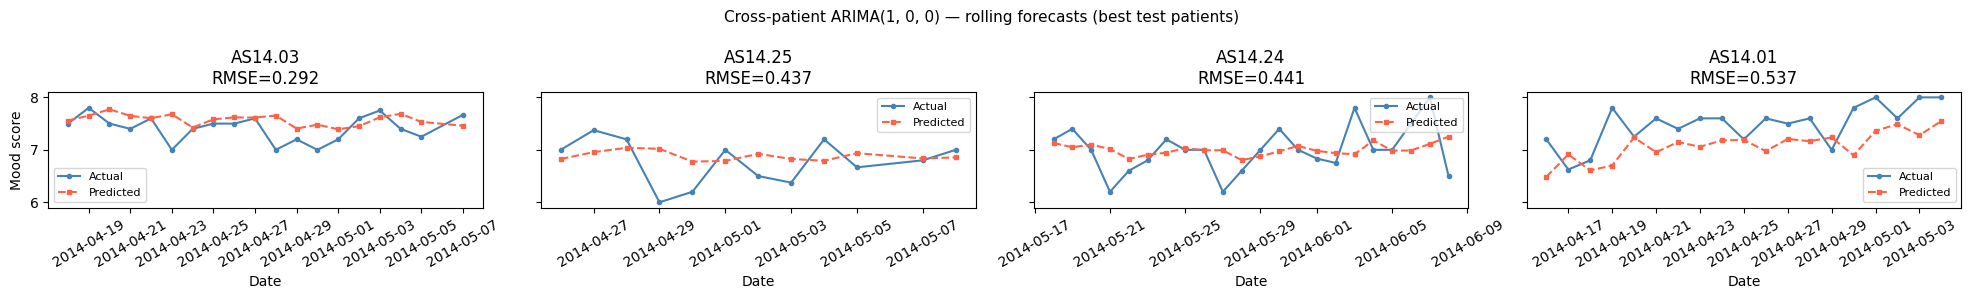

Saved: arima_cross_forecasts.png


In [33]:
test_results_sorted = sorted(test_res, key=lambda r: rmse(r["y_true"], r["y_pred"]))
n_show = min(4, len(test_results_sorted))

fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 3), sharey=True)
if n_show == 1:
    axes = [axes]

for ax, r in zip(axes, test_results_sorted[:n_show]):
    ax.plot(r["dates"], r["y_true"], "o-", label="Actual", ms=3, color="steelblue")
    ax.plot(r["dates"], r["y_pred"], "s--", label="Predicted", ms=3, color="tomato")
    patient_rmse = rmse(r["y_true"], r["y_pred"])
    ax.set_title(f"{r['patient_id']}\nRMSE={patient_rmse:.3f}")
    ax.set_xlabel("Date")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Mood score")
plt.suptitle(
    f"Cross-patient ARIMA{best_order} — rolling forecasts (best test patients)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("arima_cross_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: arima_cross_forecasts.png")

---
## 10. Summary

In [34]:
print(f"=== Cross-patient ARIMA — global order: {best_order} ===")
print(metrics_df.to_string(index=False))

print("\n=== Val RMSE ranking of candidate orders ===")
for order, r in sorted(order_val_rmse.items(), key=lambda x: x[1]):
    marker = "  ← selected" if order == best_order else ""
    print(f"  ARIMA{order}  val RMSE={r:.4f}{marker}")

=== Cross-patient ARIMA — global order: (1, 0, 0) ===
split  n_pred   RMSE    MAE      R2
train     348 0.6942 0.5035  0.3012
  val      63 0.4083 0.2776  0.1381
 test     108 0.5036 0.3940 -0.0069

=== Val RMSE ranking of candidate orders ===
  ARIMA(1, 0, 0)  val RMSE=0.4103  ← selected
  ARIMA(0, 0, 1)  val RMSE=0.4116
  ARIMA(0, 0, 2)  val RMSE=0.4184
  ARIMA(1, 0, 1)  val RMSE=0.4225
  ARIMA(0, 0, 0)  val RMSE=0.4365
  ARIMA(3, 1, 0)  val RMSE=0.4797
  ARIMA(0, 1, 1)  val RMSE=0.5014


---
## 11. Discussion

### Cross-patient vs. per-patient order selection

| Aspect | Cross-patient (this notebook) | Per-patient (`arima_regression.ipynb`) |
|---|---|---|
| Order selection | One global (p*, d*, q*) chosen by **val RMSE** across val patients | Separate auto_arima per patient |
| Model count | One order, N patient-level parameter sets | N independent models |
| New patient onboarding | Fit immediately — no order search needed | Run auto_arima on their history first |
| Risk of overfitting order | Lower — order validated on held-out val patients | Higher — short series can select spurious orders |
| Expressiveness | Same AR/MA structure for everyone | Each patient gets their own optimal structure |

### Consistency with non-temporal notebooks
The split usage now mirrors the classification and regression notebooks:
- **Train patients** → candidate generation only (auto_arima)
- **Val patients** → model/order selection (min mean val RMSE)
- **Test patients** → final evaluation only, never seen during selection

### Interpreting the global order
The selected order ARIMA(p*, d*, q*) represents the autocorrelation structure that best
describes mood dynamics *on average* across val patients. A dominant AR(1) component
(p*=1) confirms that yesterday's mood is the primary predictor for tomorrow.

### Limitations
- With only 3 val patients, the val RMSE estimate has high variance. The selected order
  may differ between runs if the dataset is re-split.
- With only ≈50 observations per patient the AIC/RMSE landscape can be flat; adjacent
  orders may perform similarly.
- Exogenous regressors (smartphone behaviour) are not yet included; ARIMAX could improve
  results further.